<p class="mlx-kicker">Part II &middot; Architecture &middot; Chapter 3</p>

# 3. Position encoding: from added sinusoids to rotations

<dl class="mlx-meta"><div><dt>Level</dt><dd>Intermediate</dd></div><div><dt>Reading</dt><dd>about 20 min</dd></div><div><dt>Hands-on</dt><dd>about 7 min on a laptop CPU</dd></div><div><dt>You should know</dt><dd>Chapter 1, dot products, sine and cosine</dd></div></dl>

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/daiyip/ml-explained/blob/main/chapters/03-position/index.ipynb)

![The three generations of explicit position encoding. Each column highlights the one part that is new: a position vector added to the token, a bias on the attention score that depends on the distance between tokens, and a rotation of the query and key by an angle proportional to position.](figures/position-lineage.svg)

## What changed, and why it works

Attention compares every token with every other token, but the comparison is a dot product between vectors, and a dot product has no idea where in the sequence either vector came from. Older architectures got order for free: a convolution only looks at a fixed window of neighbours, and a recurrent network reads tokens one at a time. The Transformer gave both up for parallelism, so it has to be told about order explicitly. Each generation in Figure 3.1 tells it in a different place.

<div class="mlx-why">
<section class="mlx-why__card mlx-why__card--1"><p class="mlx-why__n">1 &middot; Absolute</p><h3>Add a position vector to each token</h3><p><b>What changed.</b> Before the first block, a vector that depends only on the position <i>i</i> is added to the token embedding. Vaswani et al. (2017) used fixed sines and cosines; BERT and GPT (2018) learned one vector per position instead.</p><p><b>Why it works.</b> Once position is mixed into each token vector, the query and key projections can read it, so two identical characters at different places no longer look the same to attention. The cost is that content and position share the same channels, and every query-key score has to untangle them. A learned table also has no entry for positions it never saw.</p><p class="mlx-why__run">Our runs: no position 2.259, sinusoidal 2.038, learned 2.105</p></section>
<section class="mlx-why__card mlx-why__card--2"><p class="mlx-why__n">2 &middot; Relative bias</p><h3>Bias each score by the distance</h3><p><b>What changed.</b> The token vectors carry no position at all. Instead, a number that depends only on the distance <i>i &minus; j</i> is added to each attention score: learned per distance (Shaw et al., 2018; T5, 2019) or a fixed linear penalty (ALiBi, Press et al., 2021).</p><p><b>Why it works.</b> What matters for language is usually how far apart two tokens are, not their absolute index. A distance bias states that directly, never mixes position into content, and is defined for any distance, so it keeps working on sequences longer than the training ones. ALiBi's linear penalty also builds in a prior that nearby tokens matter more.</p><p class="mlx-why__run">Our runs: learned relative 2.139, ALiBi 1.952</p></section>
<section class="mlx-why__card mlx-why__card--3"><p class="mlx-why__n">3 &middot; RoPE</p><h3>Rotate the query and key</h3><p><b>What changed.</b> Each pair of query and key channels is rotated by an angle proportional to the token's position (Su et al., 2021). Nothing is added and nothing is learned. Later work (2023) stretches the angles to reach longer contexts.</p><p><b>Why it works.</b> Rotating the query by <i>i&theta;</i> and the key by <i>j&theta;</i> changes their dot product only through the difference <i>(i &minus; j)&theta;</i>, so the score sees relative position while the vector lengths, which carry content, stay untouched. Unlike a bias, the effect of distance depends on the content, because it acts inside the dot product.</p><p class="mlx-why__run">Our run: 1.881, the best of the six; at 2&times; the training length 2.007</p></section>
</div>

Read left to right, position moves out of the token vectors and into the comparison between tokens, and from absolute indices to distances. The steps below rebuild each change and test it, including on sequences twice as long as the ones the models were trained on.

## Evolution path

| Year | Step | Level | What changed |
| --- | --- | --- | --- |
| 1989-2014 | Convolution windows, recurrence | minor | order is implicit in the architecture: a fixed neighbourhood, or one token at a time |
| 2017 | Sinusoidal absolute positions | **major** | the Transformer drops recurrence and adds fixed sine and cosine vectors to the embeddings |
| 2018 | Learned absolute positions | minor | BERT and GPT learn one vector per position, up to a fixed maximum length |
| 2018-2019 | Relative position (Shaw; Transformer-XL; T5) | **major** | position enters the attention score as a function of distance, not of the index |
| 2021 | RoPE | **major** | rotate queries and keys; now the default in LLaMA, Mistral, Qwen, DeepSeek and most open LLMs |
| 2021 | ALiBi | minor | a fixed linear distance penalty per head, designed for length extrapolation |
| 2023 | RoPE scaling (position interpolation, NTK-aware, YaRN) | minor | stretch the rotation angles so a trained model reaches longer contexts |

## The lineage post-mortem: what drove each replacement?

| Replacement | Pressure that drove it | What it bought |
| --- | --- | --- |
| recurrence to explicit positions | recurrence is sequential and cannot be parallelized over the sequence | the whole sequence processed at once on a GPU |
| sinusoidal to learned | simplicity: let the model decide what position looks like | no hand design, about equal quality in practice |
| absolute to relative | language depends on distance, and absolute tables do not reach unseen lengths | translation-invariant attention and graceful longer inputs |
| relative bias to RoPE | biases add a content-independent term and need an extra lookup inside attention | relative position inside the dot product, no parameters, compatible with fast attention kernels |
| RoPE to scaled RoPE | users wanted 32k to 1M tokens of context from models trained at 2k to 8k | long context with a short fine-tune instead of retraining |

The pressure moves from *making a parallel model see order at all*, to *seeing it the right way* (by distance), to *seeing it at lengths never trained on*. Our runs reproduce the first cleanly. The second holds for ALiBi and RoPE, which beat both absolute tables, but not for our learned relative bias. On the third they show the trade-off that the field is still working through: RoPE learns best in range, but ALiBi holds up best out of range.

**Still open:** why RoPE wins in-range by as much as it does; whether causal language models need explicit positions at all (models with no position encoding do surprisingly well, Haviv et al., 2022, Kazemnejad et al., 2023); and what the cleanest way to extend context is, since every scaling method so far still benefits from fine-tuning at the new length.

## Run it yourself

The steps share this setup: the TinyShakespeare data and the chapter 1 model, whose way of handling position each step swaps out. Every model is trained with the same seed, data order and budget (300 steps on 64-character windows), so the only difference is the position encoding.

In [1]:
# Setup: works from a checkout of the repo and on Google Colab.
import pathlib, subprocess, sys

try:
    import mlexp
except ImportError:
    root = pathlib.Path.cwd().resolve().parents[1]
    if (root / "mlexp").is_dir():
        sys.path.insert(0, str(root))
    else:  # Colab: install the shared helpers from GitHub
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/daiyip/ml-explained"], check=True)
    import mlexp

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(0)
mlexp.setup_style()
device_note = "GPU available" if torch.cuda.is_available() else "running on CPU"
print(f"torch {torch.__version__}, {device_note}")

torch 2.14.1+cu130, running on CPU


In [2]:
import time
from mlexp.transformer import Attention, TransformerLM, apply_rope

torch.set_num_threads(1)  # we executed this notebook on one thread; raise it on your own machine
tok, train_ids, val_ids = mlexp.load_char_corpus()
TRAIN_LEN = 64  # every model is trained on 64-character windows
RUN = dict(steps=300, block_size=TRAIN_LEN, eval_every=100, log=False)
notebook_start = time.time()

### Step 1 (major): attention alone cannot see order

#### The idea

An attention layer computes, for each token, a weighted average of the other tokens' values, with weights from query-key dot products. Nothing in that computation refers to an index. So if you shuffle the input tokens, every output is computed from exactly the same set of vectors, and the outputs come out shuffled in the same way. Mathematically, attention without a mask is **permutation-equivariant**: `\(\mathrm{Attn}(PX) = P\,\mathrm{Attn}(X)\)` for any permutation matrix `\(P\)`.

For language this is a disaster. "dog bites man" and "man bites dog" are the same bag of tokens. Earlier architectures never had this problem: a convolution only mixes a fixed window of neighbours, so it knows who is next to whom, and a recurrent network reads tokens in order. The Transformer gave both up to process all positions in parallel.

#### Experiment: shuffle the input

We take the chapter 1 attention layer with its rotary encoding switched off and no causal mask, feed it a sequence and a shuffled copy, and check whether the outputs are the same up to the shuffle.

In [3]:
torch.manual_seed(0)
x = torch.randn(1, 10, 32)                    # one sequence of 10 token vectors
perm = torch.randperm(10)

def is_equivariant(attn):
    with torch.no_grad():
        return torch.allclose(attn(x)[:, perm], attn(x[:, perm]), atol=1e-5)

checks = {
    "no position, no mask": Attention(32, 4, causal=False, rope=False),
    "no position, causal mask": Attention(32, 4, causal=True, rope=False),
    "RoPE, no mask": Attention(32, 4, causal=False, rope=True),
}
for name, attn in checks.items():
    attn.load_state_dict(checks["no position, no mask"].state_dict())  # identical weights
    print(f"{name:26s} shuffling the input just shuffles the output: {is_equivariant(attn)}")

assert is_equivariant(checks["no position, no mask"])

no position, no mask       shuffling the input just shuffles the output: True
no position, causal mask   shuffling the input just shuffles the output: False
RoPE, no mask              shuffling the input just shuffles the output: False


Without a mask and without position information, the layer is blind to order: shuffled in, shuffled out. Adding rotary positions breaks the symmetry. So does the **causal mask**, which is less obvious: in a decoder, token *i* can only attend to tokens 0 to *i*, so the number of tokens it averages over reveals roughly where it is. This is why a decoder-only language model can learn something about order with no position encoding at all, a result we will see in the training run (Haviv et al., 2022). **[established]**

#### Experiment: a language model with no position encoding

We now build a small family of models that differ only in how position enters. `PosAttention` below is the chapter 1 attention layer with a `mode` switch; `PosLM` is the chapter 1 `TransformerLM` with an optional table added to the embeddings. Steps 2 to 5 fill in each mode.

In [4]:
def rope(x, scale=1.0, base=10000.0):
    """Rotary encoding as in mlexp.apply_rope, with two knobs used in step 5.

    scale < 1 squeezes positions (position interpolation); a larger base slows every rotation.
    """
    seq, dim = x.shape[-2], x.shape[-1]
    half = dim // 2
    freqs = base ** (-torch.arange(half, device=x.device) / half)
    angles = (torch.arange(seq, device=x.device) * scale)[:, None] * freqs[None, :]
    cos, sin = angles.cos(), angles.sin()
    x1, x2 = x[..., :half], x[..., half:]
    return torch.cat([x1 * cos - x2 * sin, x1 * sin + x2 * cos], dim=-1)


def alibi_slopes(n_heads):
    """ALiBi's fixed slopes: a geometric sequence 2^-8/h, 2^-16/h, ... one per head."""
    return torch.tensor([2 ** (-8 * (h + 1) / n_heads) for h in range(n_heads)])


class PosAttention(nn.Module):
    """Causal self-attention with a choice of how position enters the score."""

    def __init__(self, dim, n_heads, mode="none", max_dist=32):
        super().__init__()
        self.n_heads, self.mode, self.max_dist = n_heads, mode, max_dist
        self.rope_scale, self.rope_base = 1.0, 10000.0  # changed only in step 5
        self.qkv = nn.Linear(dim, 3 * dim, bias=False)
        self.out = nn.Linear(dim, dim, bias=False)
        if mode == "alibi":
            self.register_buffer("slopes", alibi_slopes(n_heads))
        if mode == "relative":  # one learned number per head and clipped distance
            self.rel_bias = nn.Parameter(torch.zeros(n_heads, max_dist + 1))

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=-1)
        q, k, v = (t.view(B, T, self.n_heads, C // self.n_heads).transpose(1, 2) for t in (q, k, v))
        if self.mode == "rope":
            q, k = rope(q, self.rope_scale, self.rope_base), rope(k, self.rope_scale, self.rope_base)
        dist = torch.arange(T)[:, None] - torch.arange(T)[None, :]   # i - j for query i, key j
        bias = torch.zeros(T, T).masked_fill(dist < 0, float("-inf"))  # causal mask
        if self.mode == "alibi":
            bias = bias - self.slopes[:, None, None] * dist.clamp(min=0)
        if self.mode == "relative":
            bias = bias + self.rel_bias[:, dist.clamp(0, self.max_dist)]
        y = F.scaled_dot_product_attention(q, k, v, attn_mask=bias)
        return self.out(y.transpose(1, 2).reshape(B, T, C))


class PosLM(TransformerLM):
    """The chapter 1 language model with a switchable position encoding."""

    def __init__(self, vocab_size, mode, dim=128, n_layers=4, n_heads=4, max_len=TRAIN_LEN):
        super().__init__(vocab_size, dim, n_layers, n_heads, rope=False)
        self.mode = mode
        for block in self.blocks:
            block.attn = PosAttention(dim, n_heads, mode if mode in ("rope", "alibi", "relative") else "none")
        if mode == "learned":
            self.pos = nn.Embedding(max_len, dim)                 # one vector per position, up to max_len
        if mode == "sinusoidal":
            self.register_buffer("pos_table", sinusoidal_table(4096, dim), persistent=False)

    def forward(self, idx, targets=None, include_aux=True):
        x = self.embed(idx)
        positions = torch.arange(idx.shape[1])
        if self.mode == "learned":
            x = x + self.pos(positions)
        if self.mode == "sinusoidal":
            x = x + self.pos_table[positions]
        for block in self.blocks:
            x = block(x)
        logits = self.head(self.norm(x))
        if targets is None:
            return logits, None
        return logits, F.cross_entropy(logits.flatten(0, 1), targets.flatten())


x = torch.randn(1, 4, 50, 32)
assert torch.allclose(rope(x), apply_rope(x)), "our rope matches the chapter 1 version"

In [5]:
models, histories = {}, {}

def train(mode):
    torch.manual_seed(0)
    model = PosLM(tok.vocab_size, mode)
    start = time.time()
    histories[mode] = mlexp.train_lm(model, train_ids, val_ids, **RUN)
    models[mode] = model
    print(f"{mode:11s} params {mlexp.count_params(model):,}  final val loss {histories[mode]['val'][-1]:.3f}  ({time.time() - start:.0f}s)")

train("none")

none        params 803,712  final val loss 2.259  (61s)


The model with no position information still learns: the causal mask gives it a rough sense of position, and many next-character predictions (finishing a common word) depend mostly on which characters are present. But it is the weakest model in this chapter, as the next steps show.

### Step 2 (major): absolute positions, sinusoidal and learned

#### The idea

The simplest fix is to make each token vector carry its position: add a vector `\(p_i\)` that depends only on the index `\(i\)` to the token embedding before the first block. Two choices of `\(p_i\)` dominated:

- **Sinusoidal** (Vaswani et al., 2017). Channel pair `\(k\)` holds `\(\sin(i\,\omega_k)\)` and `\(\cos(i\,\omega_k)\)`, with frequencies `\(\omega_k\)` falling geometrically from 1 to 1/10000. The fast channels distinguish neighbours; the slow ones distinguish distant regions, like the hands of a clock. Because `\(\sin\)` and `\(\cos\)` of `\(i + \Delta\)` are a fixed rotation of those of `\(i\)`, the authors hoped the model could attend by relative offset, and could handle lengths longer than it was trained on.
- **Learned** (BERT and GPT, 2018). Just an embedding table with one trainable vector per position. Vaswani et al. reported that it gave nearly identical results, and it is simpler. It has no vector for a position beyond the table.

<div class="mlx-box mlx-box--eq"><p class="mlx-box__label">Key equation: sinusoidal positions</p><div class="mlx-eq">$$p_{i,2k} = \sin(i\,\omega_k), \qquad p_{i,2k+1} = \cos(i\,\omega_k), \qquad \omega_k = 10000^{-2k/d}, \qquad x_i = e(t_i) + p_i$$</div><p class="mlx-eq__where">\(i\) is the position, \(k\) indexes channel pairs, \(d\) is the model width and \(e(t_i)\) the token embedding. The model only ever sees the sum \(x_i\).</p></div>

#### Minimal implementation

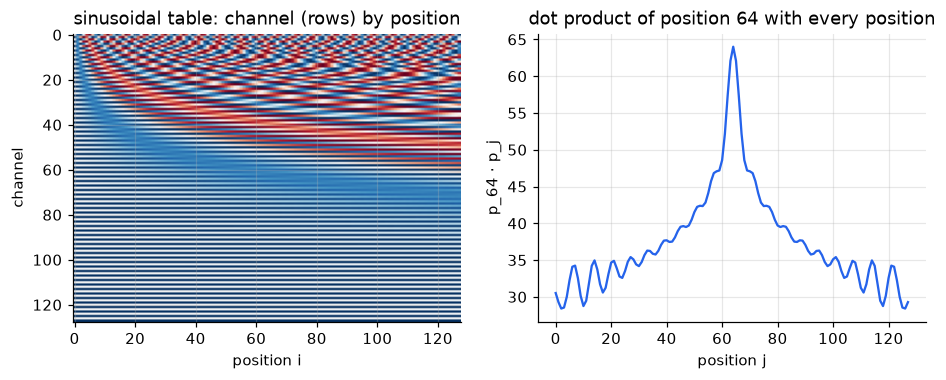

In [6]:
def sinusoidal_table(n_pos, dim):
    """Vaswani et al. (2017): sin and cos of position at geometrically spaced frequencies."""
    pos = torch.arange(n_pos)[:, None]
    omega = 10000 ** (-torch.arange(0, dim, 2) / dim)
    table = torch.zeros(n_pos, dim)
    table[:, 0::2] = torch.sin(pos * omega)
    table[:, 1::2] = torch.cos(pos * omega)
    return table


table = sinusoidal_table(128, 128)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.4))
ax1.imshow(table.T, aspect="auto", cmap="RdBu", vmin=-1, vmax=1)
ax1.set(title="sinusoidal table: channel (rows) by position", xlabel="position i", ylabel="channel")
sim = table @ table.T
ax2.plot(sim[64].numpy())
ax2.set(title="dot product of position 64 with every position", xlabel="position j", ylabel="p_64 · p_j")
ax2.grid(True);

The left panel shows the clock: fast oscillations in the first channels, slow ones further down. The right panel shows the property Vaswani et al. relied on. The dot product between two position vectors depends only on their distance and peaks at distance 0, so nearby positions look similar. But in the model the position is added to the token, and a query-key score `\((e_i + p_i)^\top W_q^\top W_k (e_j + p_j)\)` expands into four terms: content with content, content with position, position with content, and position with position. Only the last is about distance alone, and the learned projections can scramble even that.

#### Experiment: sinusoidal and learned positions

<div class="mlx-box mlx-box--predict"><p class="mlx-box__label">Predict first</p><p class="mlx-predict__q">Rank three models by validation loss: no position, sinusoidal and learned absolute positions. Is the learned table better than the fixed one?</p><details><summary>Show what happened</summary><p>Both beat no position (2.259) by a wide margin. In our run the fixed sinusoidal table (2.038) beat the learned one (2.105); with only 300 steps, the learned table has to discover what position means from scratch, while the sinusoidal one starts with useful structure.</p></details></div>

sinusoidal  params 803,712  final val loss 2.038  (60s)


learned     params 811,904  final val loss 2.105  (71s)


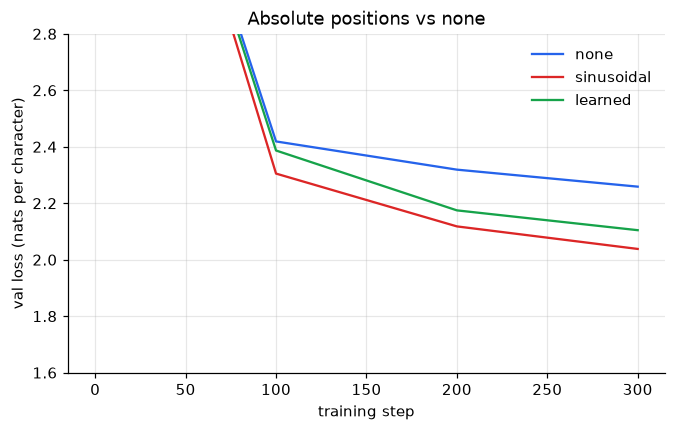

In [7]:
train("sinusoidal")
train("learned")
ax = mlexp.plot_histories({k: histories[k] for k in ["none", "sinusoidal", "learned"]}, "Absolute positions vs none")
ax.set_ylim(1.6, 2.8);

#### Why it worked: a post-mortem

**Any position beats none.** Both absolute schemes cut the loss well below the no-position model. Predicting the next character depends on the exact order of the previous few characters, and now attention can find "the character two places back". **[established]**

**Sinusoidal versus learned is close, and depends on the setting.** Vaswani et al. (2017) found them nearly identical, and BERT and GPT chose learned tables. Our short run favours the fixed table, which is plausible: a learned table starts as noise and must be trained, while the sinusoids hand the model a ready-made coordinate system. With long training the gap usually closes. **[likely]**

**The weakness is structural.** Position and content share the same channels, so every layer has to keep the two apart, and the attention score mixes them through the cross terms above. And the learned table simply stops at the training length. Step 4 tests what happens beyond it.

### Step 3 (minor): relative position as a bias on the score

Shaw, Uszkoreit and Vaswani (2018) moved position out of the token vectors and into attention itself: the score between query `\(i\)` and key `\(j\)` gets a term that depends only on the distance `\(i - j\)`, clipped at some maximum. Transformer-XL (Dai et al., 2019) and T5 (Raffel et al., 2019) refined the idea; T5 uses a single learned number per head and distance bucket, which is what we implement.

**ALiBi** (Press, Smith and Lewis, 2021) goes one step further and learns nothing: each head subtracts a fixed slope `\(m_h\)` times the distance. Heads with a steep slope look only at the last few tokens; heads with a gentle slope look far back. It was designed so that a model trained on short sequences still works on long ones.

<div class="mlx-box mlx-box--eq"><p class="mlx-box__label">Key equation: a bias on the attention score</p><div class="mlx-eq">$$s_{ij} = \frac{q_i^\top k_j}{\sqrt{d_h}} + b_h(i - j), \qquad b_h^{\text{T5}}(\Delta) = \text{learned}_h\big(\min(\Delta, \Delta_{\max})\big), \qquad b_h^{\text{ALiBi}}(\Delta) = -m_h\,\Delta$$</div><p class="mlx-eq__where">\(q_i, k_j\) carry no position information. \(m_h = 2^{-8h/H}\) for head \(h = 1, \dots, H\). Both biases are already in <code>PosAttention</code> above.</p></div>

In [8]:
train("relative")
train("alibi")
print("ALiBi slopes per head:", [round(m, 4) for m in alibi_slopes(4).tolist()])

relative    params 804,240  final val loss 2.139  (71s)


alibi       params 803,712  final val loss 1.952  (69s)
ALiBi slopes per head: [0.25, 0.0625, 0.0156, 0.0039]


ALiBi, with no position parameters at all, beats both absolute tables by a clear margin. A fixed recency penalty is a strong prior for characters, where most of the useful context is the last few letters. **[likely]** The learned per-distance bias is a surprise: in our run it is slightly worse than the learned absolute table (2.139 against 2.105). It has the same expressive power as ALiBi in principle, but its biases start at zero and must learn a shape from data in 300 steps, while T5 trained for vastly longer. We would not read more into this short run than that. **[speculative]**

The limitation of a bias is that it is added *after* the dot product. It shifts all scores at a given distance by the same amount, whatever the query is looking for. It can say "prefer nearby tokens", but not "prefer the vowel two places back".

### Step 4 (major): RoPE, rotating instead of adding

#### The idea

Su et al. (2021) asked: is there a way to put position into `\(q\)` and `\(k\)` so that their dot product depends on the content of both and on the distance `\(i - j\)`, and on nothing else? The answer is a rotation. Split the query and key channels into pairs, treat each pair as a point in a plane, and rotate it by an angle `\(i\,\theta_k\)` proportional to the position, with a different frequency `\(\theta_k\)` for each pair (the same geometric frequencies as the sinusoidal table).

The key fact is that rotations preserve dot products up to the *difference* of their angles. If the query is rotated by `\(i\theta\)` and the key by `\(j\theta\)`, their dot product equals the unrotated query dotted with the key rotated by `\((j - i)\theta\)`. The absolute positions cancel; only the distance remains. And rotations do not change a vector's length, so the content signal is not diluted by an added vector.

<div class="mlx-box mlx-box--eq"><p class="mlx-box__label">Key equation: rotary position embedding</p><div class="mlx-eq">$$\tilde q_i = R(i\theta)\,q_i, \quad \tilde k_j = R(j\theta)\,k_j \quad\Longrightarrow\quad \tilde q_i^\top \tilde k_j = q_i^\top R(i\theta)^\top R(j\theta)\, k_j = q_i^\top R\big((j - i)\theta\big)\, k_j$$</div><p class="mlx-eq__where">\(R(\alpha)\) rotates each channel pair \(k\) by \(\alpha\,\theta_k\), with \(\theta_k = 10000^{-2k/d_h}\). \(R\) is orthogonal, so \(R(a)^\top R(b) = R(b - a)\) and \(\lVert R q\rVert = \lVert q\rVert\).</p></div>

Compare this with step 2. There, the position vector is added and the score has cross terms between content and position. Here it is multiplied in, and the score is a function of content and distance alone. Compared with step 3, the distance acts *inside* the dot product, so how much it matters depends on what the query and key contain.

#### Minimal implementation

`rope` is already defined above (ten lines, the same as `mlexp.apply_rope`). We check the two properties numerically: the score depends only on distance, and the length is unchanged.

In [9]:
torch.manual_seed(0)
q, k = torch.randn(32), torch.randn(32)
seq = lambda v: v.expand(1, 1, 200, 32)        # the same vector placed at positions 0..199
rq, rk = rope(seq(q))[0, 0], rope(seq(k))[0, 0]
for i, j in [(5, 2), (50, 47), (190, 187), (190, 100)]:
    print(f"query at {i:3d}, key at {j:3d} (distance {i - j:2d}): score {rq[i] @ rk[j]:+.4f}")
print(f"length before rotation {q.norm():.4f}, after rotation to position 150: {rq[150].norm():.4f}")

query at   5, key at   2 (distance  3): score -5.1072
query at  50, key at  47 (distance  3): score -5.1072
query at 190, key at 187 (distance  3): score -5.1072
query at 190, key at 100 (distance 90): score -4.4969
length before rotation 5.6920, after rotation to position 150: 5.6920


The first three pairs are all 3 apart and give exactly the same score, at the start of the sequence and near the end. The pair 90 apart gives a different one. The length is unchanged.

#### Experiment: RoPE against everything else

rope        params 803,712  final val loss 1.881  (79s)


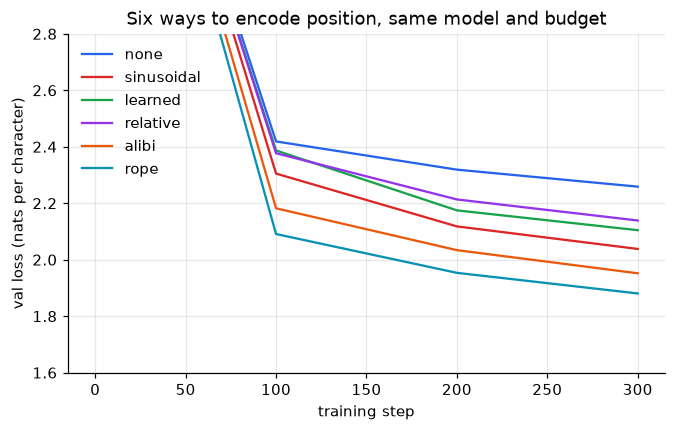

In [10]:
train("rope")
order = ["none", "sinusoidal", "learned", "relative", "alibi", "rope"]
ax = mlexp.plot_histories({k: histories[k] for k in order}, "Six ways to encode position, same model and budget")
ax.set_ylim(1.6, 2.8);

#### Experiment: twice the training length

All six models were trained on 64-character windows. What happens when we give them 128 or 256 characters? The causal mask means a token's prediction depends only on the tokens before it, so we can run each model once on 256-character windows and read off the loss at each position. Positions 0 to 63 are familiar territory; positions 64 to 127 are 2&times; the training length; 128 to 255 are 4&times;.

<div class="mlx-box mlx-box--predict"><p class="mlx-box__label">Predict first</p><p class="mlx-predict__q">For positions 64 to 127, which models keep their in-range loss, and which fall apart? Think about which ones ever saw an angle, an index or a distance larger than 63 during training.</p><details><summary>Show what happened</summary><p>The learned table cannot run at all past position 63. Sinusoidal falls apart (3.234 against 2.040 in range). ALiBi does not notice at all (1.951 against 1.967). RoPE, the no-position model and the clipped relative bias all get worse by 0.1 to 0.15 at 2&times; (RoPE: 2.007 against 1.895), and RoPE degrades much more at 4&times; (2.352).</p></details></div>

model        0-63 (trained)  64-127 (2x)  128-255 (4x)
none                  2.250        2.404         2.503
sinusoidal            2.040        3.234         3.237
learned               2.110   cannot run    cannot run
relative              2.135        2.273         2.428
alibi                 1.967        1.951         1.958
rope                  1.895        2.007         2.352


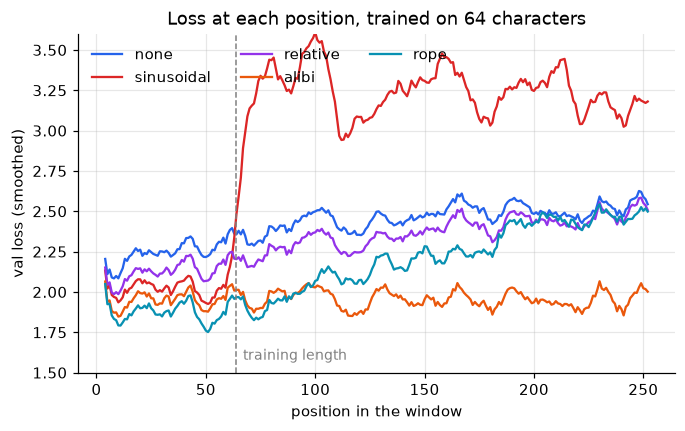

In [11]:
@torch.no_grad()
def loss_by_position(model, length=256, batches=8, batch_size=16):
    """Average next-character loss at each position, over random validation windows."""
    model.eval()
    gen = torch.Generator().manual_seed(1234)
    total = torch.zeros(length)
    for _ in range(batches):
        x, y = mlexp.get_batch(val_ids, batch_size, length, gen)
        logits, _ = model(x)
        total += F.cross_entropy(logits.transpose(1, 2), y, reduction="none").mean(0)
    return total / batches


curves, rows = {}, []
for mode in order:
    try:
        curves[mode] = c = loss_by_position(models[mode])
        rows.append((mode, c[:64].mean(), c[64:128].mean(), c[128:].mean()))
    except IndexError:
        rows.append((mode, loss_by_position(models[mode], length=64).mean(), None, None))

print(f"{'model':11s} {'0-63 (trained)':>15s} {'64-127 (2x)':>12s} {'128-255 (4x)':>13s}")
for mode, a, b, c in rows:
    fmt = lambda v: f"{v:.3f}" if v is not None else "cannot run"
    print(f"{mode:11s} {fmt(a):>15s} {fmt(b):>12s} {fmt(c):>13s}")

fig, ax = plt.subplots()
kernel = torch.ones(8) / 8
for mode, c in curves.items():  # same colour per model as in the training plot
    smooth = F.conv1d(c[None, None], kernel[None, None]).squeeze()
    ax.plot(np.arange(len(smooth)) + 4, smooth, label=mode, color=mlexp.plot.PALETTE[order.index(mode)])
ax.axvline(TRAIN_LEN, color="gray", ls="--", lw=1)
ax.text(TRAIN_LEN + 3, 1.58, "training length", color="gray", fontsize=9)
ax.set(xlabel="position in the window", ylabel="val loss (smoothed)", ylim=(1.5, 3.6),
       title="Loss at each position, trained on 64 characters")
ax.legend(frameon=False, ncol=3, loc="upper left");

#### Why it worked: a post-mortem

**RoPE is the best model in range.** With the same parameters and steps, rotating queries and keys gives the lowest loss of all six. This matches what the field found at scale: RoPE trains faster and better than absolute positions (Su et al., 2021, and EleutherAI's replications the same year), which is why nearly every open LLM since LLaMA uses it. **[established]** The mechanism we can point to is the equation above: the score depends on content and distance only, with no cross terms to untangle and no change in vector length. **[likely]** That it also beats ALiBi in range, by more than a bias would explain, suggests that letting distance interact with content matters. **[speculative]**

**Out of range, the picture flips.** At 2&times; the length RoPE is still the second-best model, but its loss rises from 1.895 to 2.007, and at 4&times; to 2.352, worse than the no-position model. ALiBi stays flat at about 1.95 all the way to 4&times;. This agrees with Press et al. (2021), who built ALiBi exactly because sinusoidal and rotary models degrade past their training length. The reason is concrete. A sinusoidal model has never seen the vectors for positions 64 and up, so it is reading inputs from outside its training distribution. A RoPE model has never seen rotation angles larger than 63&theta;; the slowest channel pairs, which barely turned during training, now reach angles the model never learned to interpret. ALiBi only ever sees "more distance means more penalty", which extends in a straight line, and the steep heads ignore far tokens anyway. **[established]**

**The other models drift.** The no-position model and the clipped relative bias have no unseen positions or distances, yet they still get worse by about 0.15 at 2&times;. A likely cause is that each query now averages over more keys, which flattens attention in a way the model never saw; the no-position model also relies on the causal mask to count tokens, and those counts are now out of range. **[likely]** That a model with no position encoding degrades about as gracefully as one with a relative bias is part of why the question "do decoders need position encodings at all?" is still being asked (Kazemnejad et al., 2023). **[likely]**

**Caveat on our numbers.** These runs use a 64-character training window and 300 steps. Across three seeds the in-range ranking (RoPE, ALiBi, sinusoidal, learned, relative bias, none) came out the same every time, and so did every extrapolation result; the spreads are listed at the end of the chapter.

### Step 5 (minor): stretching RoPE for longer contexts

RoPE won in range, and it is what almost every LLM uses, so the industry needed a way around its weakness out of range. The fixes, all from 2023, change the rotation angles at test time so that a longer sequence only produces angles the model has already seen:

- **Position interpolation** (Chen et al., 2023): multiply every position by `\(L_{\text{train}} / L_{\text{new}}\)`. A sequence twice as long is squeezed into the old range of angles, at the cost of neighbours being only half a step apart.
- **NTK-aware scaling** (bloc97, 2023): raise the base 10000 instead. The fast channels, which tell neighbours apart, barely change, and the slow channels, the ones that would go out of range, are stretched the most. YaRN (Peng et al., 2023) refines the split between the two.

Each is usually followed by a short fine-tune at the new length. Here we try them with no fine-tuning at all, on the RoPE model from step 4, evaluated at 2&times; the training length.

In [12]:
def set_rope(model, scale=1.0, base=10000.0):
    for block in model.blocks:
        block.attn.rope_scale, block.attn.rope_base = scale, base

rope_model, d_head = models["rope"], 128 // 4
settings = {
    "plain RoPE": dict(),
    "position interpolation (x 1/2)": dict(scale=0.5),
    "NTK-aware (base x 2^(d/(d-2)))": dict(base=10000.0 * 2 ** (d_head / (d_head - 2))),
}
print(f"{'RoPE setting':32s} {'0-63':>7s} {'64-127':>7s}")
for name, kw in settings.items():
    set_rope(rope_model, **kw)
    c = loss_by_position(rope_model, length=128)
    print(f"{name:32s} {c[:64].mean():7.3f} {c[64:].mean():7.3f}")
set_rope(rope_model)  # restore
print(f"ALiBi, for reference             {curves['alibi'][:64].mean():7.3f} {curves['alibi'][64:128].mean():7.3f}")
print(f"\nwhole notebook: {(time.time() - notebook_start) / 60:.1f} min")

RoPE setting                        0-63  64-127


plain RoPE                         1.899   2.028


position interpolation (x 1/2)     2.477   2.566


NTK-aware (base x 2^(d/(d-2)))     1.908   1.965
ALiBi, for reference               1.967   1.951

whole notebook: 7.0 min


Squeezing the positions without fine-tuning backfires: position interpolation makes the model worse everywhere, even in range (2.477 instead of 1.899), because neighbouring characters are now only half a step apart in angle, and a character model depends on telling neighbours apart. Chen et al. (2023) always pair interpolation with a short fine-tune at the new length, and even then report a small loss of quality inside the original window; a character model, which leans heavily on the last few characters, is probably more sensitive to this than a word-piece model. **[likely]**

NTK-aware scaling does what it was designed to do. It leaves the fast channels almost untouched, so the in-range loss barely moves (1.899 to 1.908), and it brings the slow channels back into the range of angles seen in training, so the loss at 2&times; drops from 2.028 to 1.965, close to ALiBi's 1.951, with no training at all. **[likely]**, given one model; the gain held in all three seeds we ran.

This is the state of the art in miniature. RoPE won because it is the best encoding in range. Its weakness out of range is now patched by rescaling its angles, usually plus a short fine-tune at the new length, as in Code Llama, LLaMA 3 and Qwen. Extrapolation that is free, as with ALiBi, has not been enough to displace it.

## Across three seeds

The numbers on this page come from one run, seed 0. We reran the whole notebook twice more with every random seed shifted by 1 and by 2, which changes the initial weights, the batches and the evaluation samples (the `Seed runs` workflow in the repository does this for any chapter). A gap between two runs means something only when it is clearly larger than their spread.

| Run | This page (seed 0) | Mean ± sd, 3 seeds | Seeds 0 / 1 / 2 |
| --- | --- | --- | --- |
| none | 2.259 | 2.240 ± 0.027 | 2.259 / 2.252 / 2.209 |
| sinusoidal | 2.038 | 2.011 ± 0.024 | 2.038 / 2.004 / 1.991 |
| learned | 2.105 | 2.096 ± 0.022 | 2.105 / 2.113 / 2.071 |
| relative bias | 2.139 | 2.130 ± 0.017 | 2.139 / 2.141 / 2.110 |
| ALiBi | 1.952 | 1.938 ± 0.018 | 1.952 / 1.944 / 1.918 |
| RoPE | 1.881 | 1.867 ± 0.021 | 1.881 / 1.876 / 1.843 |
| sinusoidal at 2× length | 3.234 | 3.099 ± 0.120 | 3.234 / 3.060 / 3.003 |
| ALiBi at 2× length | 1.951 | 1.917 ± 0.030 | 1.951 / 1.907 / 1.893 |
| RoPE at 2× length | 2.007 | 2.005 ± 0.054 | 2.007 / 2.058 / 1.951 |
| RoPE at 4× length | 2.352 | 2.413 ± 0.130 | 2.352 / 2.562 / 2.325 |
| RoPE + NTK-aware scaling at 2× | 1.908 | 1.888 ± 0.021 | 1.908 / 1.889 / 1.866 |

The in-range ranking was the same in every seed, and every extrapolation result held. RoPE's loss at 4× the training length varies most (spread 0.13), but it is far worse than ALiBi in every seed.

## Recap

<div class="mlx-box mlx-box--objectives"><p class="mlx-box__label">Recap</p><p>You should now be able to:</p><ol><li>Show that attention without position information is blind to word order, and explain why a causal mask partly breaks that symmetry.</li><li>Implement sinusoidal, learned, relative-bias, ALiBi and rotary position encodings in a few lines each.</li><li>Derive why rotating queries and keys makes the attention score depend only on the distance between tokens.</li><li>Explain why models fail beyond their training length, and how ALiBi and RoPE scaling address it.</li></ol></div>

<div class="mlx-box mlx-box--check"><p class="mlx-box__label">Check your understanding</p><details><summary>You shuffle the tokens of a sentence and feed it to an attention layer with no mask and no position encoding. What happens to the output?</summary><p>It is the same set of output vectors, shuffled in the same way. Each output is a weighted average over all tokens, and neither the weights nor the values depend on where a token sits.</p></details><details><summary>Why can a learned absolute position table not be used on a sequence longer than it was trained on, while ALiBi can?</summary><p>The table has one trained vector per position and simply has no row for position 64 and beyond. ALiBi computes its bias from the distance with a fixed formula, so it is defined for any distance, and "further away means less attention" stays sensible.</p></details><details><summary>RoPE rotates the query by angle i&theta; and the key by j&theta;. Why does their dot product depend only on i &minus; j?</summary><p>Rotations are orthogonal, so R(i&theta;)<sup>T</sup>R(j&theta;) = R((j &minus; i)&theta;). The absolute angles cancel and only the difference remains. Rotations also preserve length, so the content signal is not altered.</p></details><details><summary>Position interpolation multiplies positions by 1/2 to run a model at twice its training length. What does it give up?</summary><p>Neighbouring tokens are now only half a step apart in angle, a spacing the model never saw. The fast channels that tell neighbours apart become less precise, which is why a short fine-tune at the new length is usually needed, and why NTK-aware scaling leaves those channels nearly unchanged.</p></details></div>

## Further reading

- Vaswani et al., 2017, [Attention Is All You Need](https://arxiv.org/abs/1706.03762): sinusoidal positions.
- Shaw, Uszkoreit and Vaswani, 2018, [Self-Attention with Relative Position Representations](https://arxiv.org/abs/1803.02155).
- Raffel et al., 2019, [Exploring the Limits of Transfer Learning with a Unified Text-to-Text Transformer](https://arxiv.org/abs/1910.10683): T5's relative bias buckets.
- Su et al., 2021, [RoFormer: Enhanced Transformer with Rotary Position Embedding](https://arxiv.org/abs/2104.09864): RoPE.
- Press, Smith and Lewis, 2021, [Train Short, Test Long: Attention with Linear Biases Enables Input Length Extrapolation](https://arxiv.org/abs/2108.12409): ALiBi.
- Haviv et al., 2022, [Transformer Language Models without Positional Encodings Still Learn Positional Information](https://arxiv.org/abs/2203.16634).
- Chen et al., 2023, [Extending Context Window of Large Language Models via Positional Interpolation](https://arxiv.org/abs/2306.15595).
- Peng et al., 2023, [YaRN: Efficient Context Window Extension of Large Language Models](https://arxiv.org/abs/2309.00071).